# Intro

In [ ]:
!pwd

In [ ]:
!ls

In [ ]:
# Working with file path
# Python data structure
# Function documentation

In [ ]:
# Working with file path
# !pwd 
# !ls
# !cd

In [ ]:
# Python data structure

In [ ]:
websites = [
    {'site': 'Twitter', 'type': 'Social Media', 'views': 10000, 'active_users': 200000},
    {'site': 'Facebook', 'type': 'Social Media', 'views': 35000, 'active_users': 500000},
    {'site': 'NYT', 'type': 'News media', 'views': 78000, 'active_users': 156000},    
    {'site': 'YouTube', 'type': 'Video platform', 'views': 18000, 'active_users': 289000},
    {'site': 'Vimeo', 'type': 'Video platform', 'views': 300, 'active_users': 1580},
    {'site': 'USA Today', 'type': 'News media', 'views': 4800, 'active_users': 5608},
]
pd_website = pd.DataFrame(websites)

In [ ]:
len(pd_website)

In [ ]:
# Function documentation
len?

In [ ]:
help(len)

In [ ]:
pd_website.head()

In [ ]:
# help(pd_website.head)
pd_website.head?

In [ ]:
# To check only the argument
import inspect
inspect.signature(df.head)

In [ ]:
import inspect
inspect.signature(len)

# Challenge 1 - Loading and analyzing data

For this challenge we will work with social media data.  Use the file named socialmedia_challenge1.csv. Load that file using ```pandas``` and:
1. Display the first 5 rows. - S
2. Check which columns the dataframe contains. - S
3. Check which columns have missing values. - S
4. Check how many entries are available in the dataset. - S
5. Calculate the average and the standard deviation of a form of engagement (e.g., number of likes, comments or shares). -S
6. Calculate the average, minimum and maximum number of another engagement metric. -S
7. What are the most three popular post the dataset. -S
8. Who are the top three most popular posters. - M
9. What are the most popular days and hours for the post. - M
10. Create a frequency plot of engagement (engagment in the x-axis and frequency of engagment in the y-axis). - (Bonus)
11. Anonymize the data (Bonus), imagine this dataset contains personal data and you want to share it with other researchers.

  - Basic anonymization: Identify which column(s) would let someone re-identify a real person. Replace that column with a consistent anonymous ID (e.g., using `.astype("category").cat.codes`) so individual users can no longer be identified by name. Re-run your answers to Questions 5–9 on this anonymized dataset and confirm you arrive at the exact same observations as before, just with anonymous IDs instead of usernames.

 -  Behavioral re-identification: Even without usernames, could someone still figure out who a specific anonymous user is, just from patterns in their behavior (e.g., posting frequency, consistently high engagement)? Which user(s) in this dataset would be most at risk of this kind of re-identification, and why? Is this something the first anonymization actually solves, or only partially?

 -   Word choice as a behavioral signature: Instead of (or in addition to) numeric patterns, look at the actual `post_text` content. For each anonymized `user_id`, find their single most frequently used post and what share of their posts it accounts for. Are some users' text signatures unmistakable? Could you match a real person's known writing habits (a phrase they always use) to one of these anonymous `user_id`s, without ever seeing their username?

### Soln

In [1]:
# load the data
import pandas as pd
df_data = pd.read_csv('data/socialmedia_challenge1.csv')
len(df_data)

5000

In [ ]:
# 1
df_data.head(5)

In [ ]:
# 2
df_data.columns 

In [ ]:
# 3
df_data.isna().sum()

In [ ]:
# 4
len(df_data)

In [ ]:
# 5
df_data.likes.mean(), df_data.likes.std()

In [ ]:
# 6
df_data.comments.mean(), df_data.comments.min(), df_data.comments.max()

In [ ]:
# 7
df_data.nlargest(3, "likes")[["post_id", "username", "likes"]]

In [ ]:
# 8
df_data.groupby("username")["likes"].sum().sort_values(ascending=False).head(3)

In [ ]:
# 9
df_data["timestamp"] = pd.to_datetime(df_data["timestamp"])
df_data["day_name"] = df_data.timestamp.dt.day_name()
df_data["hour"] = df_data.timestamp.dt.hour
print (df_data.day_name.value_counts().head(3))
print (df_data.hour.value_counts().head(3))

<Axes: xlabel='likes'>

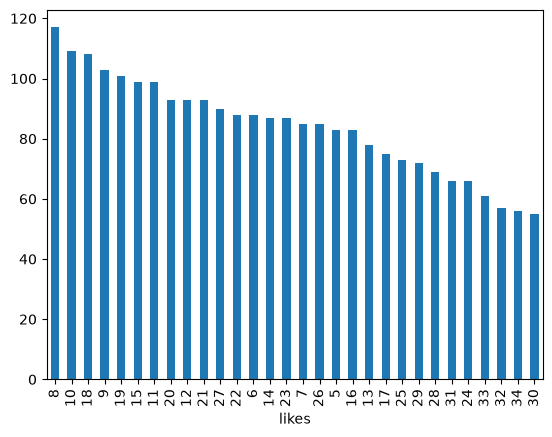

In [2]:
# 10

df = df_data
# 2. count how many posts got exactly 0 likes, exactly 1 like, exactly 2 likes, etc.
counts = df["likes"].value_counts().sort_index()

# 3. turn it into its own dataframe
dist_df = counts.reset_index()
dist_df.columns = ["likes", "frequency"]

# sort so the most common like-counts appear first
dist_df_sorted = dist_df.sort_values("frequency", ascending=False)
# dist_df_sorted.head(15)

# 4. plot only the first 30 values (where most posts are) so the chart stays readable
dist_df_sorted.head(30).plot(x="likes", y="frequency", kind="bar", legend=False)

# Challenge 2 - Working with messy data

Social media data are often "messy" — missing data, duplicate information, or unwanted observations. In this challenge, we will practice pre-processing noisy data. Use the file `socialmedia_challenge2.csv`. Complete the following using ```pandas``` and:

1. Load the dataset and display the first 5 rows. — S
2. Check which languages are present and how many entries exist per language. — S
3. Identify and remove duplicate rows. — M
4. Identify and remove missing (NA) values. — M
5. Select only the rows where `language == "en"`. — M
6. Save this cleaned, English-only selection to a new file. — S
7. How many rows were dropped at each cleaning step (duplicates, irrelevant, non-English)? Does that change your analysis of the "most popular post/poster" answers from Challenge 1? — M

### Soln

In [ ]:
# !pip install langdetect

In [ ]:
!ls data/

In [ ]:
#1
import pandas as pd
pd_data2 = pd.read_csv('data/socialmedia_challenge2.csv')
pd_data2.head()

In [ ]:
#2
pd_data2.language.value_counts()
# pd_data2["language"].value_counts()
# pd_data2.groupby("language").size()

In [ ]:
#3
print (pd_data2.duplicated().sum())  
print (len(pd_data2))
df_nodup = pd_data2.drop_duplicates() 
print (len(df_nodup))
df_nodup.duplicated().sum()

In [ ]:
#4
print (len(df_nodup))
df_clean = df_nodup.dropna(subset=["post_text"])
# df_clean = df_nodup.dropna() #or to drop every row with missing column value 
print (len(df_clean))

In [ ]:
#5
# Option A
print(len(df_clean))
df_en = df_clean[df_clean["language"] == "en"]
print(len(df_en))
# # Option B
# df_en = df_clean.query("language == 'en'")
# # Option C
# df_en = df_clean.loc[df_clean.language == "en"]

In [ ]:
#6
# Option A - use index=false to avoid adding index
df_en.to_csv("data/socialmedia_clean_en.csv")

In [ ]:
!ls data/

In [ ]:
import pandas as pd
pd_socialmedia_clean_en = pd.read_csv('data/socialmedia_clean_en.csv')
pd_socialmedia_clean_en.language.value_counts()

In [ ]:
#7
print(len(pd_data2) - len(df_nodup))       
print(len(df_nodup) - len(df_clean)) 
print(len(df_clean) - len(df_en))   